In [1]:
# Alignment (including self-alignment) of strings or other sequences,
# possibly weighted by feature similarity.
# todo: add other self-alignment methods, see wyfst/extra
import re, sys
import heapq
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

#import panphon
sys.path.append("/home/colin/Library/Python/string2string")
from string2string.alignment import SmithWaterman

from phonopy import config as phon_config
from phonopy import (features, strings)

fm = features.read_features()

/home/colin/Library/miniconda3/envs/py3_14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    ipa syllabic stress long consonantal sonorant continuant delayed.release  \
0     ɒ        +      -    -           -        +          +               0   
1     ɑ        +      -    -           -        +          +               0   
2     ɶ        +      -    -           -        +          +               0   
3     a        +      -    -           -        +          +               0   
4     æ        +      -    -           -        +          +               0   
..   ..      ...    ...  ...         ...      ...        ...             ...   
138   ɹ        -      -    -           -        +          +               0   
139   ʋ        -      -    -           -        +          +               0   
140   ʍ        -      -    -           -        -          +               +   
141   ɦ        -      -    -           -        -          +               +   
142   h        -      -    -           -        -          +               +   

    approximant tap  ... distributed st

In [2]:
def adjust_indices(align, offset):
    """
    Adjust the indices of an alignment to account for the fact that the
    beginning of the second string is offset relative to the first string.
    """
    if align.indices is None:
        return None
    span1 = align.indices[0]
    span2 = align.indices[1]
    span2 = (span2[0]+offset, span2[1]+offset)
    return (span1, span2)


def markup_self_alignment(x, align, offset):
    align_strings = align.strings
    align_indices = align.indices
    if align_strings is None or align_strings[0]=='' or align_strings[1]=='':
        return None
    if align_indices is None:
        return None
    span1, span2 = adjust_indices(align, offset)
    y = x[:span1[0]] + ['⟨'] + x[span1[0]:span1[1]] + ['⟩'] + x[span1[1]:span2[0]] + ['⟨'] + x[span2[0]:span2[1]] + ['⟩'] + x[span2[1]:]
    y = ' '.join(y)
    return y


def incremental_self_alignment(x, sep=' '):
    """
    Process each prefix of a string, finding the best alignment of
    non-overlapping substrings using Smith-Waterman.
    """
    if sep!='' and sep is not None:
        x = x.split(sep)
    xlen = len(x)

    # Initialize the alignment object
    gap_char = phon_config.epsilon

    def match_func(seg1, seg2):
        return features.segment_similarity(fm, seg1, seg2, sim_func = features.overlap_similarity, feature_weights=None, offset=-0.75, indel_weight=-1.0)
    aligner = SmithWaterman(match_func=match_func, gap_char=gap_char)
    #aligner = SmithWaterman()
    
    # Initialize an empty list to store the results
    ret = set()
    
    # Iterative over prefixes.
    for i in range(2, xlen + 1):
        prefix = x[:i]
        # Find best alignment within a prefix.
        align_best = None
        score_best = None
        offset_best = None
        for j in range(1, len(prefix)):
            prefix_ = prefix[:j]
            _suffix = prefix[j:]
            align = aligner.get_alignment( \
                prefix_, _suffix, return_indices=True)
            score = aligner.get_alignment_score( \
                align.strings[0], align.strings[1])
            # score /= (xlen / 2) # normalize by string length
            # score /= (i / 2) # normalize by prefix length
            ret.add((-score, align))
            if score_best is None or score > score_best:
                score_best = score
                align_best = align
                offset_best = j
        #print(align_best, score_best)
        print(f'prefix {i}, {markup_self_alignment(x, align_best, offset_best)}, {-score_best}')

    ret = list(ret)
    heapq.heapify(ret)
    return ret

In [ ]:
examples = [
    "satu-satuɲa", "kəkaseh-kəkaseh", "sə-səpet", "asal-usol",
    "llama-llama", "doggy-oggy", "piggy-wiggy", "snalnal", "snalfak",
    "wofewo"
]
x = examples[2]
x = [x[i] for i in range(len(x)) if x[i] != '-']
#x = re.sub('[-]', '', x)
print(x)
aligns = incremental_self_alignment(x, sep='')
#pprint(aligns)

['w', 'o', 'f', 'e', 'w', 'o']
prefix 2, ⟨ w ⟩ ⟨ o ⟩ f e w o, -0.1428571428571428
prefix 3, ⟨ w ⟩ ⟨ o ⟩ f e w o, -0.1428571428571428
prefix 4, ⟨ w ⟩ ⟨ o ⟩ f e w o, -0.1428571428571428
prefix 5, ⟨ w ⟩ o f e ⟨ w ⟩ o, -0.2499999999999999
prefix 6, ⟨ w o ⟩ f e ⟨ w o ⟩, -0.4999999999999998


['s', 'ə', 's', 'ə'] ['p', 'e', 't']
4
Alignment(strings=(('s', 'ə', 's'), ('p', 'e', 't')), indices=((0, 3), (0, 3)), score=None, score_matrix=array([[0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.0356742 , 0.        , 0.13888889],
       [0.        , 0.        , 0.21424563, 0.        ],
       [0.        , 0.0356742 , 0.        , 0.35313452],
       [0.        , 0.        , 0.21424563, 0.        ]]))
[[0.         0.         0.         0.        ]
 [0.         0.0356742  0.         0.13888889]
 [0.         0.         0.21424563 0.        ]
 [0.         0.0356742  0.         0.35313452]
 [0.         0.         0.21424563 0.        ]]


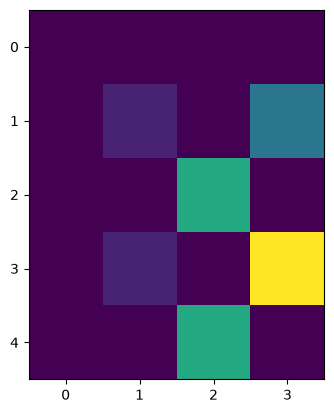

In [7]:
#x = "s a t u s a t u ɲ a"
x = 's ə s ə p e t'
y = x.split(' ')
y_ = y[:4]
_y = y[4:]
print(y_, _y)

def match_func(seg1, seg2):
    return features.segment_similarity(fm, seg1, seg2, sim_func = features.overlap_similarity, feature_weights=None, offset=-0.75, indel_weight=-1.0)
aligner = SmithWaterman(match_func=match_func, gap_char=phon_config.epsilon)
align = aligner.get_alignment(y_, _y, return_indices=True, return_score_matrix=True)
print(len(align))
pprint(align)

print(align.score_matrix)
plt.imshow(align.score_matrix)
plt.show()
